In [1]:
import numpy as np
import genbart as gb
import matplotlib.pyplot as plt

In [ ]:
def compare_raw_logml_vi(
    n,
    p,
    genX,
    x_args,
    genY,
    y_args,
    n_repeats = 1,
    n_boot = 1,
):
    raw_results = []
    logml_results = []

    X = genX(**x_args(n, p))
    y = genY(**y_args(X))

    for _ in range(n_boot):
        idx = np.random.choice(len(y), len(y), replace=True)

        for _ in range(n_repeats):
            model = gb.RegBart(m=20).fit(X=X[idx], y=y[idx])

            raw_results.append(model.variable_inclusion("raw"))
            logml_results.append(model.variable_inclusion("logml"))

    return np.mean(raw_results, axis=0), np.mean(logml_results, axis=0)

In [114]:
def plot_vi_results(results, n, p_set, important_vars=None):
    plt.style.use("seaborn-v0_8-whitegrid")

    fig, axes = plt.subplots(
        len(p_set),
        1,
        figsize=(8, 4 * len(p_set))
    )

    if len(p_set) == 1:
        axes = [axes]

    fig.suptitle("Variable importance", fontsize=16)

    for ax, p in zip(axes, p_set):
        raw = results[f"{p}_raw"]
        logml = results[f"{p}_logml"]
        x = np.arange(p)

        ax.plot(
            x,
            raw,
            color="royalblue",
            marker="o",
            markersize=5,
            label="raw"
        )

        ax.plot(
            x,
            logml,
            color="darkorange",
            marker="^",
            markersize=5,
            label="logml"
        )

        if important_vars is not None:
            important = np.array([i for i in important_vars if i < p])

            ax.scatter(
                important,
                raw[important],
                color="crimson",
                edgecolor="black",
                s=70,
                zorder=3,
                label="important variable"
            )

            ax.scatter(
                important,
                logml[important],
                color="crimson",
                edgecolor="black",
                s=70,
                marker="^",
                zorder=3
            )

        ax.set_title(f"$n = {n}$, $p = {p}$")
        ax.set_xlabel("Variable")
        ax.set_ylabel("Variable importance")
        ax.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Continuous Response and Continuous Predictors 

In [91]:
n = 500
p_set = [50, 200]
s2 = 1
n_repeats = 5

### Irrelevant Predictors

In [130]:
results_irr = {}

for p in p_set:
    raw_mean, logml_mean = compare_raw_logml_vi(
        n=n,
        p=p,
        genX=np.random.uniform,
        x_args=lambda n, p: {
            "low": 0,
            "high": 1,
            "size": (n, p)
        },
        genY=np.random.uniform,
        y_args=lambda X: {
            "low": 0,
            "high": 1,
            "size": len(X)
        },
        n_boot=5,
        n_repeats=1
    )

    results_irr[str(p) + "_raw"] = raw_mean
    results_irr[str(p) + "_logml"] = logml_mean

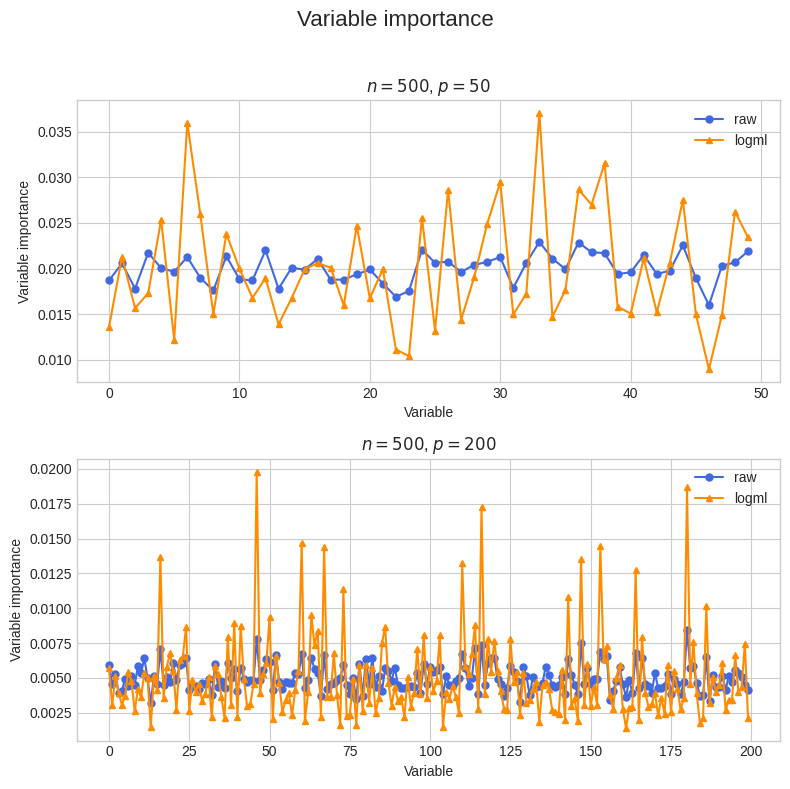

In [131]:
plot_vi_results(results_irr, n, p_set)

### Friedman Function

In [93]:
def friedman(x: np.ndarray, s2: float):
    if x.ndim == 1:
        x = x[None]
    if x.shape[1] < 5:
        raise ValueError("Input of Friedman function needs at least 5 elements.")

    y = (10 * np.sin(np.pi * x[:, 0] * x[:, 1])
        + 20 * (x[:, 2] - 0.5)**2
        + 10 * x[:, 3]
        + 5 * x[:, 4])
    
    return y + np.random.normal(0, s2, y.shape[0])

In [ ]:
results_fried = {}

for p in p_set:
    raw_mean, logml_mean = compare_raw_logml_vi(
        n=n,
        p=p,
        genX=np.random.uniform,
        x_args=lambda n, p: {
            "low": 0,
            "high": 1,
            "size": (n, p)
        },
        genY=friedman,
        y_args=lambda X: {
            "x": X ,
            "s2": s2,
        },
        n_repeats=n_repeats
    )

    results_fried[str(p) + "_raw"] = raw_mean
    results_fried[str(p) + "_logml"] = logml_mean

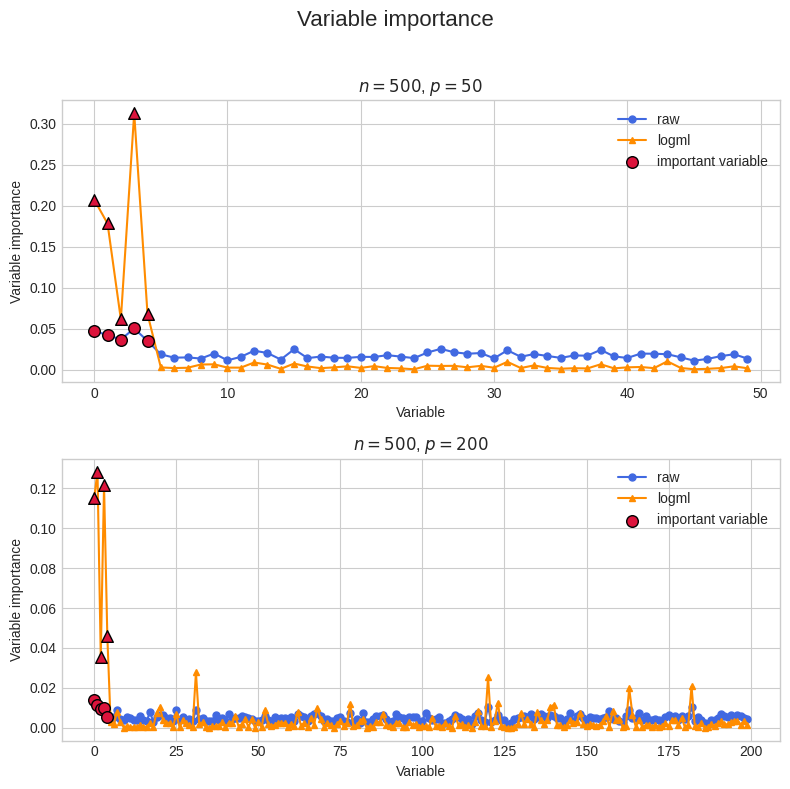

In [116]:
plot_vi_results(results_fried, n, p_set, [0, 1, 2, 3, 4])

### Correlated Continous Predictors

In [132]:
results_corr = {}

for p in p_set:
    S = 0.3 ** np.abs(np.subtract.outer(np.arange(p), np.arange(p)))
    raw_mean, logml_mean = compare_raw_logml_vi(
        n=n,
        p=p,
        genX=np.random.multivariate_normal,
        x_args=lambda n, p: {
            "mean": np.zeros(p),
            "cov": S,
            "size": n
        },
        genY=lambda x: (2 * x[:, 0] * x[:, 3] + 2 * x[:, 6] * x[:, 9]),
        y_args=lambda X: {
            "x": X},
        n_boot=5,
        n_repeats=1
    )

    results_corr[str(p) + "_raw"] = raw_mean
    results_corr[str(p) + "_logml"] = logml_mean

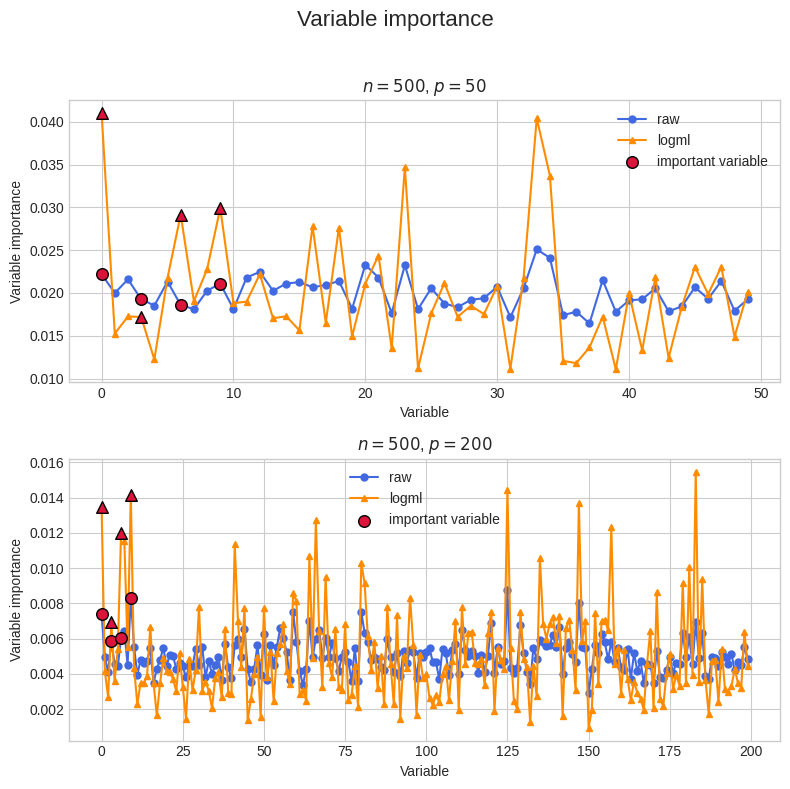

In [133]:
plot_vi_results(results_corr, n, p_set, [0, 3, 6, 9])

## Contiuous Response and Mixed Predictors

In [ ]:
n_set = [500, 1000]
p_set = [50, 200]

### Friedman Function with Bernoulli and Uniform Precitors

In [144]:
results_fried_mix = {}

for p in p_set:
    raw_mean, logml_mean = compare_raw_logml_vi(
        n=n,
        p=p,
        genX=lambda n, p: (
            np.concat((
                np.random.binomial(2, 0.5, (n, np.ceil(p/2).astype(int))),
                np.random.uniform(0, 1, (n, p - np.ceil(p/2).astype(int)))
                ),
                axis=1
            )
        ),
        x_args=lambda n, p: {
            "p": p,
            "n": n
        },
        genY=lambda x, p, s2: (
            friedman(x[:, [p//2, p//2 + 1, p//2 + 2, 0, 1]], s2)
        ),
        y_args=lambda x: {
            "x": x,
            "p": p,
            "s2": 1
        },
        n_boot=5,
        n_repeats=1
    )

    results_fried_mix[str(p) + "_raw"] = raw_mean
    results_fried_mix[str(p) + "_logml"] = logml_mean

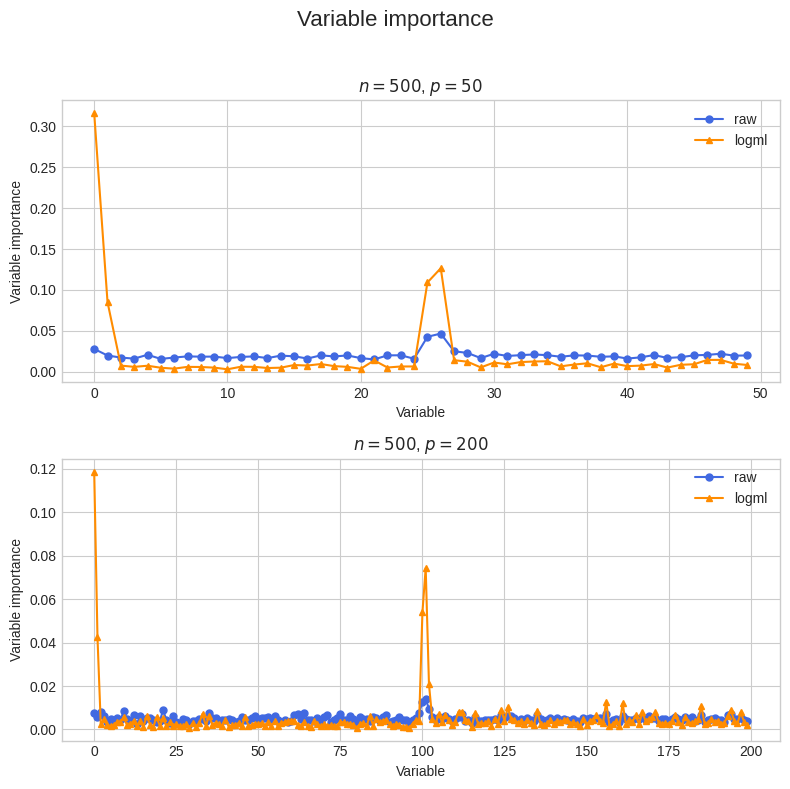

In [145]:
plot_vi_results(results_fried_mix, n, p_set)

### Multiple Bernoulli and Normal Predictors

In [47]:
def response_f(x: np.ndarray):
    if x.ndim == 1:
        x = x[None]
    return(
        -4 + x[:, 0]
        + np.sin(np.pi * x[:, 0] * x[:, 43])
        - x[:, 20] + 0.6 * x[:, 40] * x[:, 41]
        - np.exp(-2*(x[:, 41] + 1)**2)
        - x[:, 42]**2 + 0.5 * x[:, 43]
    )

In [69]:
results_bernorm = {}
S = np.full((44, 44), 0.3)
np.fill_diagonal(S, 1)

for N in [n]:
    raw_key = str(p) + "_raw"
    logml_key = str(p) + "_logml"

    results_bernorm[raw_key] = []
    results_bernorm[logml_key] = []

    for repeat in range(n_repeats):
        X = np.concat((
            np.random.binomial(2, 0.2, (N, 20)),
            np.random.binomial(2, 0.5, (N, 20)),
            np.random.multivariate_normal(np.zeros(44), S, N)
            ),
            axis=1
        )
        y = response_f(X) + np.random.normal(0, s2, n)
        model = gb.RegBart(m=20).fit(X=X, y=y)
        results_bernorm[raw_key].append(model.variable_inclusion("raw"))
        results_bernorm[logml_key].append(model.variable_inclusion("logml"))

/tmp/ipykernel_78784/4078974124.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


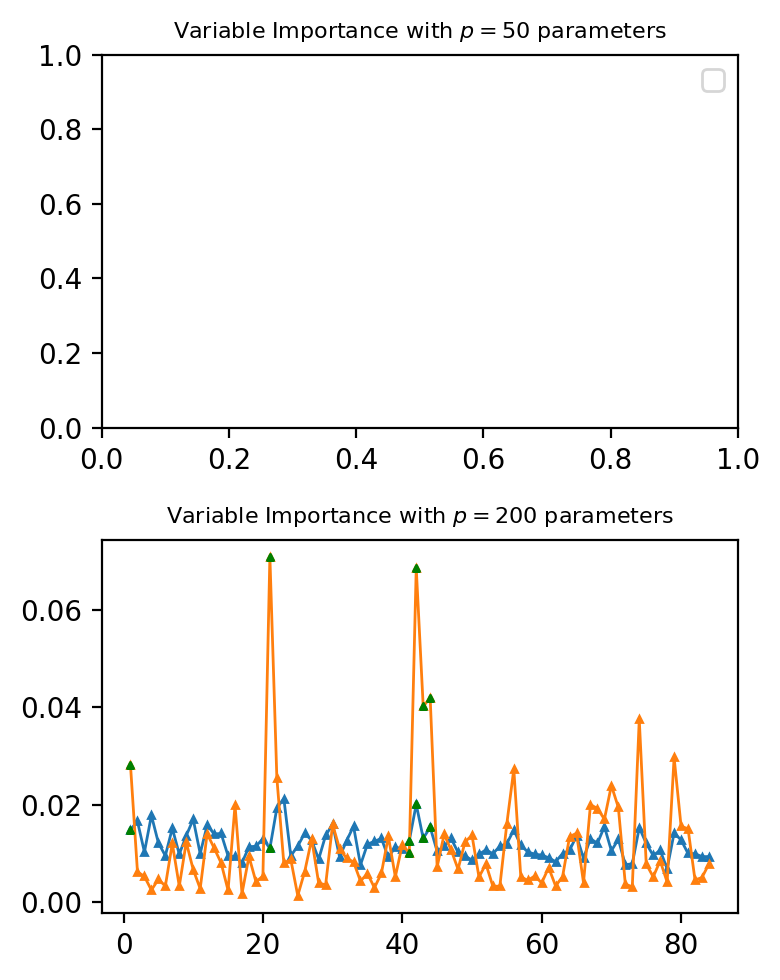

In [70]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5), dpi=200)
idx = np.array([1, 44, 21, 41, 42, 43])
p=84

label_raw = str(200)+"_raw"
label_logml = str(200)+"_logml"

axes[i].plot(
    np.arange(1, p+1),
    results_bernorm[label_raw][0],
    label=label_raw,
    linewidth=1,
    marker="^",
    markersize=2
)
axes[i].scatter(idx,
                results_bernorm[label_raw][0][idx-1],
                marker="^",
                s=5,
                c="green",
                zorder=3,
                label="Relevant predictors")
axes[i].plot(
    np.arange(1, p+1),
    results_bernorm[label_logml][0],
    label=label_logml,
    linewidth=1,
    marker="^",
    markersize=2
)
axes[i].scatter(idx,
                results_bernorm[label_logml][0][idx-1],
                marker="^",
                s=5,
                c="green",
                zorder=3)

axes[0].set_title(f"Variable Importance with $p=50$ parameters", size=8)
axes[1].set_title(f"Variable Importance with $p=200$ parameters", size=8)
axes[0].legend()

plt.tight_layout()
plt.show()